In [1]:
import tensorflow as tf

In [2]:
breeds = ["beagle","bernese_mountain_dog","doberman","labrador_retriever","siberian_husky"]

In [3]:
args = {"labels":"inferred",
        "label_mode":"categorical",
        "batch_size":32,
        "image_size":(256,256),
        "seed":1,
        "validation_split":.2,
        "class_names":breeds}

In [4]:
train = tf.keras.utils.image_dataset_from_directory("dog_images/images", subset = "training", **args)

Found 926 files belonging to 5 classes.
Using 741 files for training.


I0000 00:00:1771549468.816931    8265 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9558 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
test = tf.keras.utils.image_dataset_from_directory("dog_images/images", subset = "validation", **args)

Found 926 files belonging to 5 classes.
Using 185 files for validation.


In [6]:
first = train.take(1)
first

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [7]:
images, labels = list(first)[0]

2026-02-19 20:04:40.385992: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
first_image = images[0]
first_image[:3, :3, 0]

<tf.Tensor: shape=(3, 3), dtype=float32, numpy=
array([[17.658463, 25.686066, 29.847656],
       [18.993622, 26.17189 , 29.454437],
       [17.373474, 19.348282, 25.176407]], dtype=float32)>

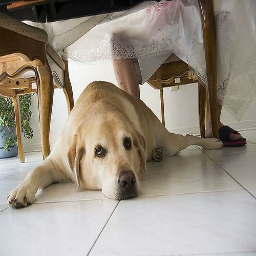

In [10]:
from PIL import Image

Image.fromarray(first_image.numpy().astype("uint8"))

In [11]:
labels[0]

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 0., 0., 1., 0.], dtype=float32)>

In [12]:
train = train.cache().prefetch(buffer_size = tf.data.AUTOTUNE)
test = test.cache().prefetch(buffer_size = tf.data.AUTOTUNE)

In [20]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

model  = Sequential([
    layers.Rescaling(1/255),
    layers.Conv2D(16, 3, padding = "same", activation = "relu", input_shape = (256,256,3)),
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dense(5)
])

/home/shreyash/projects/image_classification/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer = "adam",
    loss = tf.keras.losses.CategoricalCrossentropy(from_logits = True),
    metrics = ["accuracy"]
)

In [22]:
history = model.fit(train, epochs = 5, validation_data = test, verbose = 1)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.2132 - loss: 19.2072 - val_accuracy: 0.2541 - val_loss: 3.1804
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3846 - loss: 1.6838 - val_accuracy: 0.2649 - val_loss: 1.6391
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7247 - loss: 0.9618 - val_accuracy: 0.3243 - val_loss: 2.0046
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9393 - loss: 0.2911 - val_accuracy: 0.2270 - val_loss: 2.3852
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9879 - loss: 0.0795 - val_accuracy: 0.2324 - val_loss: 3.2297


In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1048576)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │   134,217,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 402,656,849 (1.50 GB)

 Trainable params: 134,218,949 (512.00 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 268,437,900 (1.00 GB)

<Axes: >

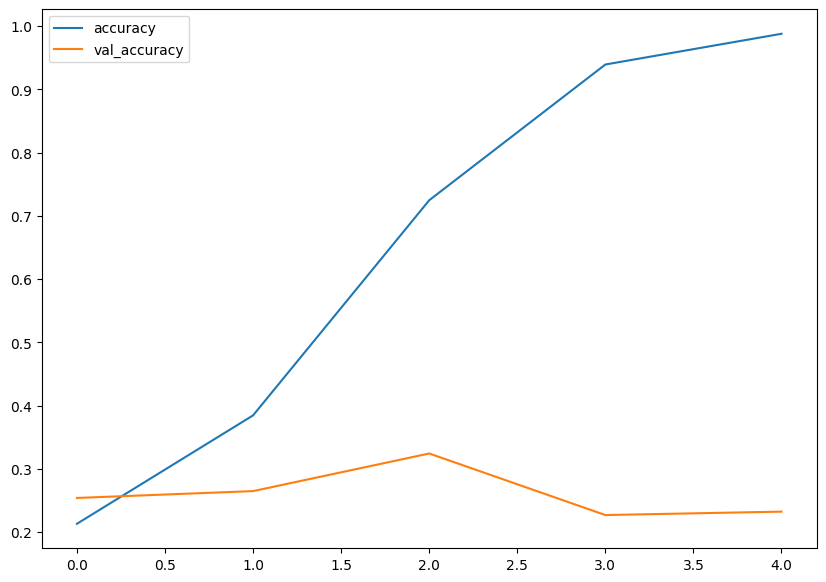

In [24]:
import pandas as pd

history_df = pd.DataFrame(history.history)
history_df[["accuracy", "val_accuracy"]].plot(figsize = (10, 7))

In [25]:
def train_model(network, epochs = 5):
    model = Sequential(network)
    model.compile(
        optimizer = "adam",
        loss = tf.keras.losses.CategoricalCrossentropy(from_logits = True),
        metrics = ["accuracy"]
    )
    history = model.fit(train, epochs = epochs, validation_data = test, verbose = 1)
    history_df = pd.DataFrame.from_dict(history.history)
    return history_df, model

In [28]:
network = [
    layers.Rescaling(1/255),
    layers.Conv2D(16, 4, padding = "same", activation = "relu", input_shape = (256,256,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 4, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 4, padding = "same", activation = "relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation = "relu"),
    layers.Dense(5)
]

history_df, model = train_model(network, epochs = 10)

Epoch 1/10


/home/shreyash/projects/image_classification/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.2524 - loss: 1.9068 - val_accuracy: 0.2865 - val_loss: 1.6023
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3482 - loss: 1.5769 - val_accuracy: 0.3514 - val_loss: 1.5745
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3954 - loss: 1.4567 - val_accuracy: 0.4054 - val_loss: 1.4525
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4966 - loss: 1.2555 - val_accuracy: 0.3405 - val_loss: 1.4687
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6248 - loss: 0.9500 - val_accuracy: 0.3405 - val_loss: 1.7222
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7665 - loss: 0.6266 - val_accuracy: 0.3027 - val_loss: 2.2927
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8691 - loss: 0.3683 - val_accuracy: 0.2270 - val_loss: 3.8606
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8785 - loss: 0.3790 - val_accuracy: 0.2865 - val_loss: 3

<Axes: >

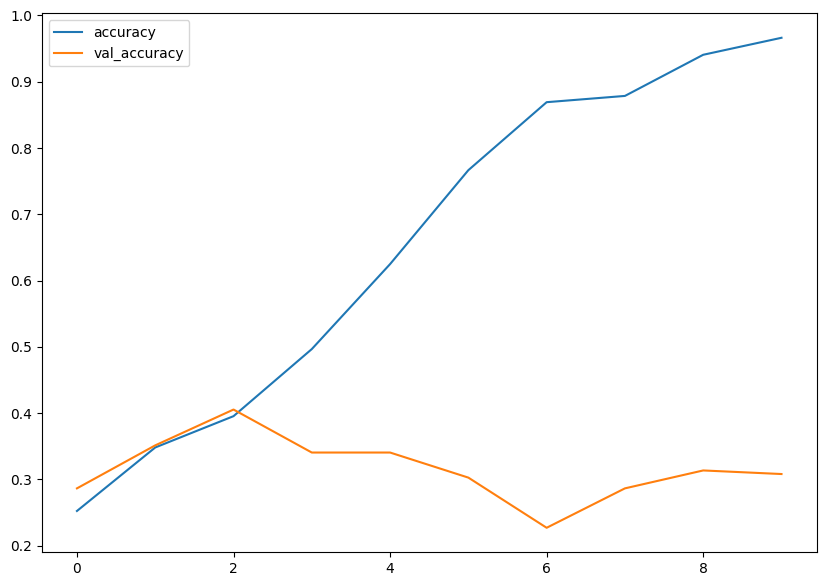

In [29]:
history_df[["accuracy", "val_accuracy"]].plot(figsize = (10, 7))

In [30]:
data_augmentation = Sequential([
    layers.RandomFlip("horizontal", seed=1),
    layers.RandomRotation(0.2, seed = 1),
    layers.RandomZoom(0.2, seed = 1),
])

In [31]:
full_network = [data_augmentation] + network
history_df, model = train_model(full_network, epochs = 10)

Epoch 1/10


E0000 00:00:1771550684.090795    8265 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_5_1/dropout_1_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


24/24 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.3414 - loss: 1.7414 - val_accuracy: 0.2757 - val_loss: 1.4986
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3954 - loss: 1.4656 - val_accuracy: 0.3081 - val_loss: 1.5413
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4372 - loss: 1.3357 - val_accuracy: 0.3946 - val_loss: 1.4792
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.4777 - loss: 1.3346 - val_accuracy: 0.3514 - val_loss: 1.4556
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5007 - loss: 1.2632 - val_accuracy: 0.3081 - val_loss: 1.4670
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5385 - loss: 1.2372 - val_accuracy: 0.3568 - val_loss: 1.4983
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.5412 - loss: 1.1626 - val_accuracy: 0.3568 - val_loss: 1.5228
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5344 - loss: 1.1744 - val_accuracy: 0.4000 - val_loss: 1.

<Axes: >

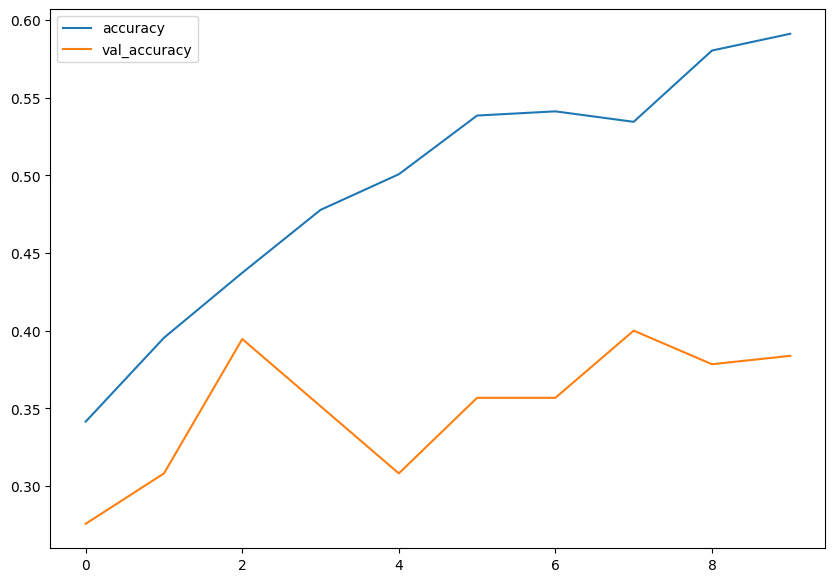

In [33]:
history_df[["accuracy", "val_accuracy"]].plot(figsize = (10, 7))

In [34]:
preds = model.predict(test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [35]:
import numpy as np
predicted_class = np.argmax(preds, axis = 1)
predicted_class

array([3, 2, 1, 3, 4, 2, 0, 4, 2, 1, 1, 4, 3, 1, 2, 4, 3, 0, 0, 3, 0, 4,
       2, 3, 3, 2, 0, 0, 3, 3, 3, 1, 4, 2, 3, 2, 1, 1, 1, 1, 0, 0, 0, 4,
       4, 1, 1, 1, 2, 2, 0, 3, 0, 1, 2, 4, 4, 4, 0, 1, 0, 2, 4, 1, 4, 1,
       3, 0, 0, 3, 4, 1, 1, 4, 1, 0, 2, 4, 2, 3, 2, 1, 2, 3, 2, 1, 3, 0,
       1, 2, 1, 4, 4, 1, 3, 4, 0, 4, 1, 2, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1,
       4, 4, 1, 3, 1, 0, 3, 1, 1, 2, 0, 2, 2, 1, 2, 1, 0, 2, 2, 4, 1, 1,
       1, 1, 2, 0, 4, 0, 2, 0, 0, 0, 2, 4, 4, 2, 0, 0, 3, 3, 0, 0, 2, 1,
       1, 2, 1, 2, 2, 2, 4, 0, 4, 4, 2, 2, 2, 1, 2, 3, 0, 1, 0, 1, 0, 1,
       0, 2, 3, 0, 0, 1, 1, 1, 2])

In [38]:
actual_class = np.concatenate([y for x, y in test], axis = 0).argmax(axis = 1)
actual_class

2026-02-19 20:29:14.194850: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


array([3, 1, 1, 2, 3, 3, 0, 0, 4, 2, 2, 4, 4, 3, 0, 4, 3, 2, 3, 3, 4, 4,
       3, 0, 1, 2, 1, 4, 0, 1, 3, 4, 0, 0, 2, 3, 2, 4, 1, 4, 3, 0, 3, 4,
       3, 1, 1, 3, 1, 1, 4, 4, 0, 2, 2, 1, 4, 4, 0, 2, 4, 1, 1, 1, 4, 0,
       2, 3, 0, 0, 1, 1, 2, 4, 1, 3, 3, 0, 1, 4, 1, 2, 2, 1, 3, 1, 4, 3,
       1, 2, 1, 4, 4, 4, 3, 4, 4, 4, 2, 1, 4, 0, 1, 4, 1, 1, 0, 2, 2, 4,
       1, 4, 1, 4, 1, 3, 1, 1, 0, 3, 0, 2, 2, 1, 1, 1, 4, 1, 4, 0, 2, 1,
       0, 3, 0, 3, 4, 0, 0, 3, 0, 0, 1, 2, 4, 1, 0, 3, 0, 3, 0, 0, 3, 2,
       3, 1, 0, 3, 3, 2, 4, 0, 4, 1, 2, 1, 3, 4, 3, 2, 3, 1, 4, 0, 0, 2,
       3, 2, 2, 0, 3, 3, 1, 1, 2])

In [39]:
import itertools

actual_image = [x.numpy() for x, y in test]
actual_image = list(itertools.chain.from_iterable(actual_image))

In [40]:
actual_image = [Image.fromarray(x.astype("uint8")) for x in actual_image]

In [44]:
pred_df = pd.DataFrame(zip(predicted_class, actual_class, actual_image), columns = ["predicted", "actual", "image"])

In [45]:
pred_df["predicted"]=pred_df["predicted"].apply(lambda x: breeds[x])
pred_df["actual"]=pred_df["actual"].apply(lambda x: breeds[x])
pred_df.head()

,predicted,actual,image
0,labrador_retriever,labrador_retriever,<PIL.Image.Image image mode=RGB size=256x256 a...
1,doberman,bernese_mountain_dog,<PIL.Image.Image image mode=RGB size=256x256 a...
2,bernese_mountain_dog,bernese_mountain_dog,<PIL.Image.Image image mode=RGB size=256x256 a...
3,labrador_retriever,doberman,<PIL.Image.Image image mode=RGB size=256x256 a...
4,siberian_husky,labrador_retriever,<PIL.Image.Image image mode=RGB size=256x256 a...


,predicted,actual,image
0,labrador_retriever,labrador_retriever,
1,doberman,bernese_mountain_dog,
2,bernese_mountain_dog,bernese_mountain_dog,
3,labrador_retriever,doberman,
4,siberian_husky,labrador_retriever,
5,doberman,labrador_retriever,
6,beagle,beagle,
7,siberian_husky,beagle,
8,doberman,siberian_husky,
9,bernese_mountain_dog,doberman,

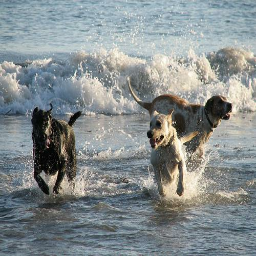
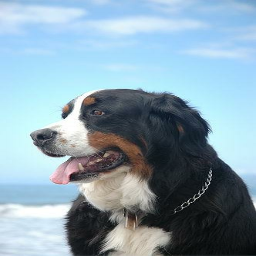
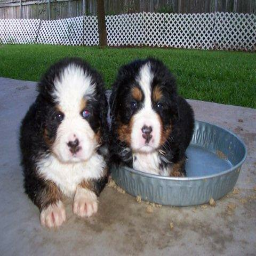
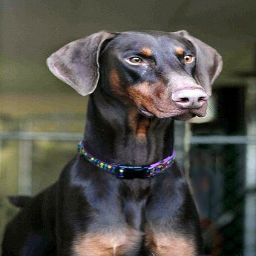
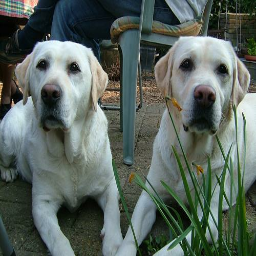
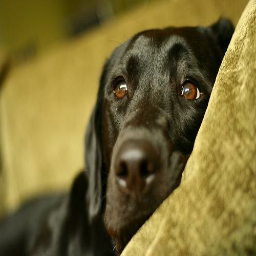
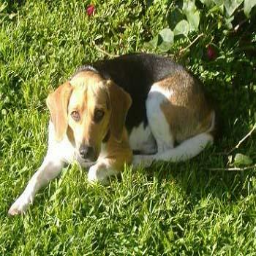
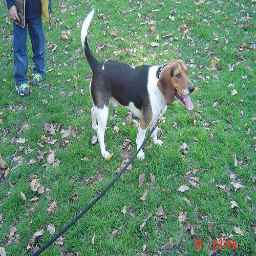
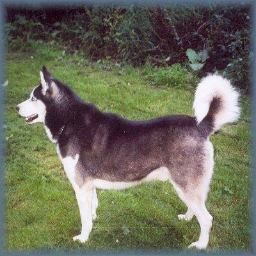
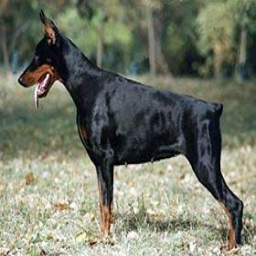

In [49]:
import base64
import io

def image_formatter(img):
    with io.BytesIO() as buffer:
        img.save(buffer, format = "PNG")
        img_str = base64.b64encode(buffer.getvalue()).decode()
    return f'<img src="data:image/jpeg;base64,{img_str}"/>'

pred_df.head(10).style.format({"image": image_formatter})